In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import time, pickle, warnings
warnings.filterwarnings("ignore")

## Data Loading

In [2]:
df0 = pd.read_csv("data/data.csv")
print(f"data shape: {df0.shape}")
df0["time"] = pd.to_datetime(df0["time"])
df0.head(3)

data shape: (17668, 32)


,time,Gas for paper,Hourly Production,Total water,Quantitative measurement of coiling scan frame,#1 Turbine motor side pressure,#1 Turbine Free Side Pressure,#1 Turbine Negative Pressure,#1 Turbine Negative Pressure.1,#1 Turbine Main Motor Current,...,#3 Turbine Negative Pressure.1,#3 Turbine Main Motor Current,#3 Vacuum Pump Motor Side Vibration,#3 Vacuum Pump Free Side Vibration,#4 Turbine Free Side Pressure,#4 Turbine Negative Pressure,#4 Turbine Negative Pressure.1,#4 Turbine Main Motor Current,#4 Vacuum Pump Motor Side vibration,#4 Vacuum pump free side vibration
0,2022-05-25 14:06:00,0.987,43.7,100,163.3,-32.3,-40.4,-36.3,93.0,79.4,...,91.0,83.0,0.7,13.0,-51.6,-51.6,100.0,73.1,13.3,2.4
1,2022-05-25 14:07:00,0.993,43.7,100,163.2,-32.5,-40.4,-36.4,93.0,79.1,...,91.0,83.0,0.7,13.2,-51.6,-51.6,100.0,73.4,13.3,2.4
2,2022-05-25 14:08:00,0.989,43.8,101,162.9,-32.7,-40.3,-36.5,93.0,78.7,...,91.0,83.2,0.7,13.4,-51.5,-51.5,100.0,73.4,13.3,2.4


#### Select Features and Target

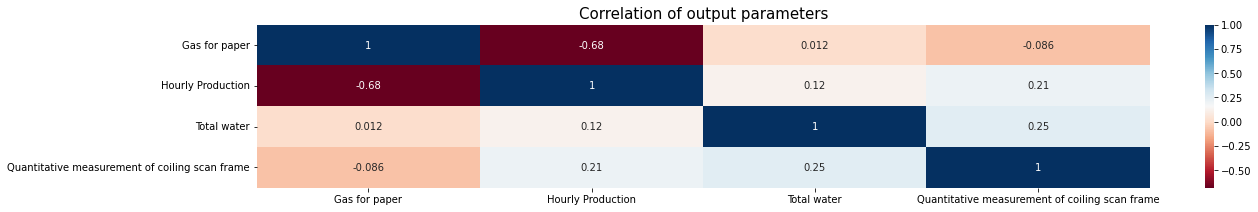

In [3]:
plt.figure(figsize=(20, 3))
sns.heatmap(data = df0.iloc[:, 1:5].corr(), annot=True, cmap = 'RdBu')
plt.title('Correlation of output parameters', fontsize = 15)
plt.show()

In [4]:
target = "Hourly Production"
features = df0.columns[5:].to_list()

In [5]:
df = df0.copy()
df = df.set_index("time")
df = df[[target] + features]
df.head(3)

,Hourly Production,#1 Turbine motor side pressure,#1 Turbine Free Side Pressure,#1 Turbine Negative Pressure,#1 Turbine Negative Pressure.1,#1 Turbine Main Motor Current,#1 Vacuum Pump Motor Side vibration,#1 Free side vibration of vacuum pump,#2 Turbine motor side pressure,#2 Turbine free side pressure,...,#3 Turbine Negative Pressure.1,#3 Turbine Main Motor Current,#3 Vacuum Pump Motor Side Vibration,#3 Vacuum Pump Free Side Vibration,#4 Turbine Free Side Pressure,#4 Turbine Negative Pressure,#4 Turbine Negative Pressure.1,#4 Turbine Main Motor Current,#4 Vacuum Pump Motor Side vibration,#4 Vacuum pump free side vibration
time,,,,,,,,,,,,,,,,,,,,,
2022-05-25 14:06:00,43.7,-32.3,-40.4,-36.3,93.0,79.4,12.2,5.6,-49.0,-61.9,...,91.0,83.0,0.7,13.0,-51.6,-51.6,100.0,73.1,13.3,2.4
2022-05-25 14:07:00,43.7,-32.5,-40.4,-36.4,93.0,79.1,11.8,5.6,-49.0,-61.8,...,91.0,83.0,0.7,13.2,-51.6,-51.6,100.0,73.4,13.3,2.4
2022-05-25 14:08:00,43.8,-32.7,-40.3,-36.5,93.0,78.7,11.8,5.6,-49.0,-61.8,...,91.0,83.2,0.7,13.4,-51.5,-51.5,100.0,73.4,13.3,2.4


## EDA & Feature Engineering

#### Basic information

In [6]:
df.info()
# 沒有類別變數

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17668 entries, 2022-05-25 14:06:00 to 2022-07-04 23:59:00
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hourly Production                      17668 non-null  float64
 1   #1 Turbine motor side pressure         17668 non-null  float64
 2   #1 Turbine Free Side Pressure          17668 non-null  float64
 3   #1 Turbine Negative Pressure           17668 non-null  float64
 4   #1 Turbine Negative Pressure.1         17668 non-null  float64
 5   #1 Turbine Main Motor Current          17668 non-null  float64
 6   #1 Vacuum Pump Motor Side vibration    17668 non-null  float64
 7   #1 Free side vibration of vacuum pump  17668 non-null  float64
 8   #2 Turbine motor side pressure         17668 non-null  float64
 9   #2 Turbine free side pressure          17668 non-null  float64
 10  #2 Turbine negative pressure       

In [7]:
df.describe().T
# fearure包含負數，轉換時須注意
# #4 Turbine Negative Pressure.1為constant feature，但須回推機台參數的最佳解，不可刪除

,count,mean,std,min,25%,50%,75%,max
Hourly Production,17668.0,39.280960,7.723688,0.0,39.1,41.0,42.2,45.6
#1 Turbine motor side pressure,17668.0,-30.602536,7.344057,-42.7,-36.1,-32.6,-27.2,-0.1
#1 Turbine Free Side Pressure,17668.0,-37.164331,6.845119,-41.1,-39.4,-38.8,-37.4,0.4
#1 Turbine Negative Pressure,17668.0,-33.884786,6.552035,-41.5,-37.2,-35.6,-32.7,0.1
#1 Turbine Negative Pressure.1,17668.0,89.862916,7.552495,50.0,90.0,91.0,93.0,95.0
#1 Turbine Main Motor Current,17668.0,75.751228,15.725865,0.3,69.8,76.6,86.4,101.1
#1 Vacuum Pump Motor Side vibration,17668.0,13.626828,2.302482,0.5,13.6,13.9,14.5,26.4
#1 Free side vibration of vacuum pump,17668.0,6.325074,1.433624,0.4,6.0,6.4,6.6,29.9
#2 Turbine motor side pressure,17668.0,-47.942110,8.581029,-50.7,-50.1,-49.2,-48.9,0.5
#2 Turbine free side pressure,17668.0,-60.187701,10.581498,-66.7,-62.4,-62.2,-61.8,-0.4


In [8]:
df.isnull().sum().sum()
# 無 missing value

0

#### Target Analysis

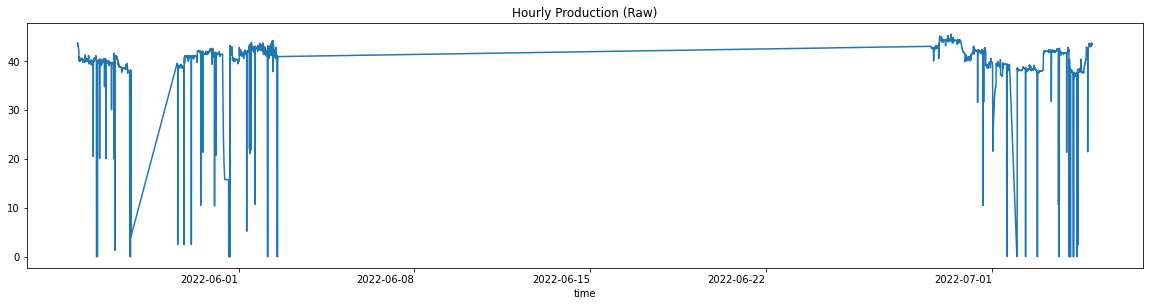

In [9]:
plt.figure(figsize=(20, 5)) 
df['Hourly Production'].plot()
plt.title('Hourly Production (Raw)')
plt.xticks(rotation=0)
plt.show()
# 正常產出應該要在40上下，Target有許多異常狀態，須砍掉異常sample

In [10]:
# Target異常狀態處理
df = df[df['Hourly Production'] > 30]
df.shape
# 刪除903(17668 - 16765)個樣本

(16765, 28)

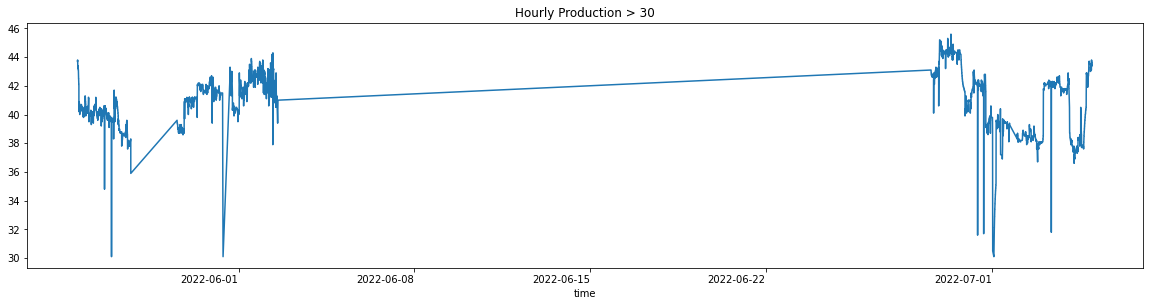

In [11]:
plt.figure(figsize=(20, 5)) 
df['Hourly Production'].plot()
plt.title('Hourly Production > 30')
plt.xticks(rotation=0)
plt.show()

#### Correlation

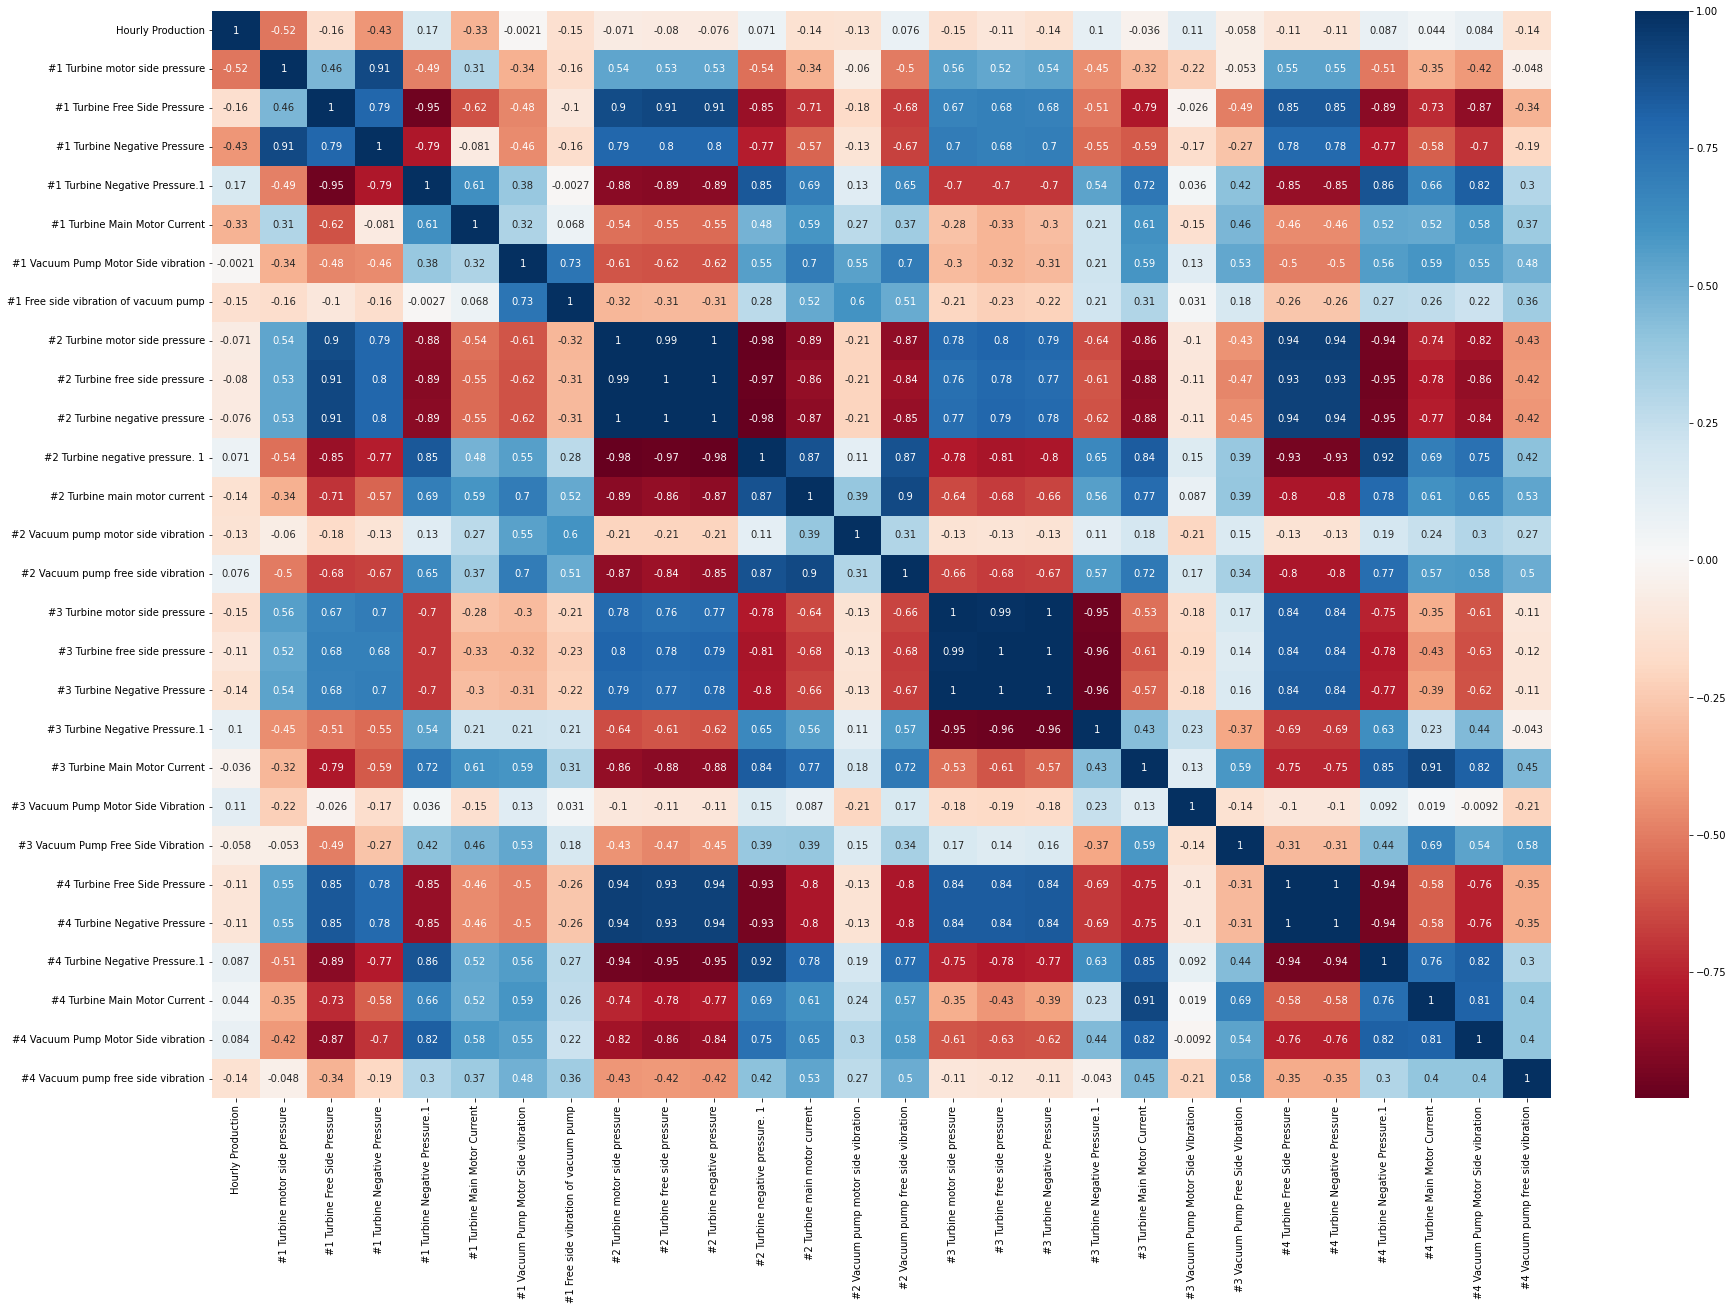

In [12]:
plt.figure(figsize=(30, 20))
sns.heatmap(data = df.corr(), annot=True, cmap = 'RdBu')
plt.show()

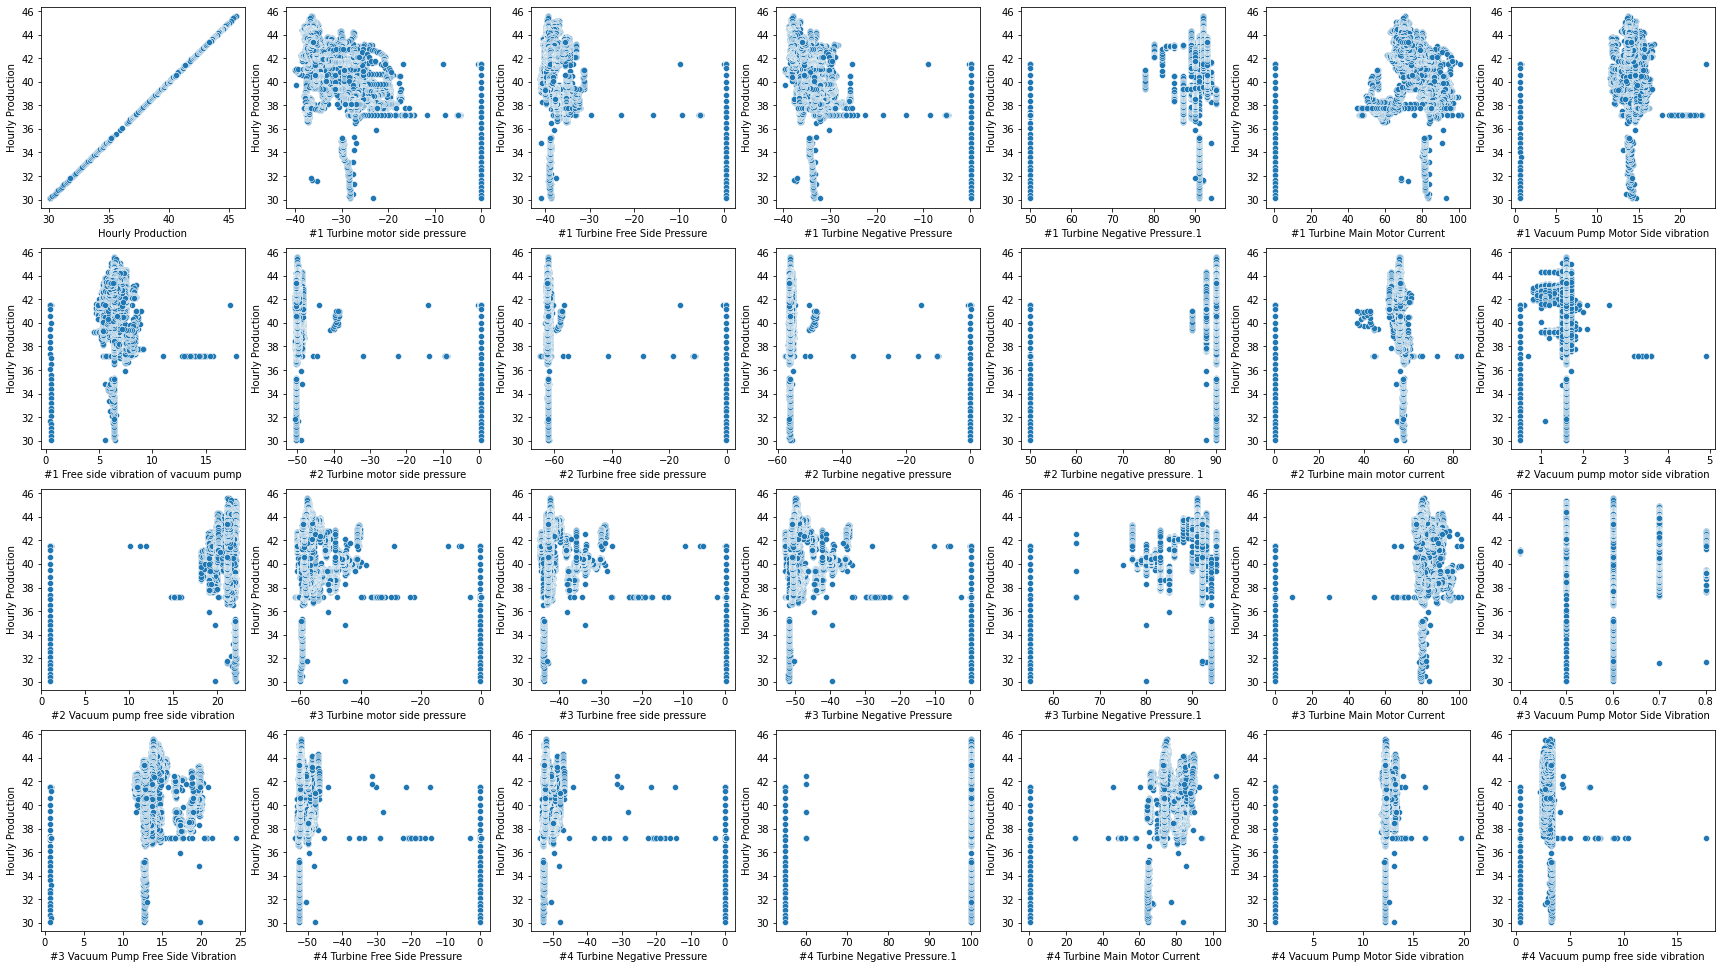

In [13]:
# "Relationship between features and target"
a, b = 4, 7
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 17))
for i in range(a):
    for j in range(b):
        sns.scatterplot(x = df.columns[k], y = target, data = df, ax = ax[i, j])
        k += 1
plt.show()

#### Outlier

In [14]:
# KMeans分類偵測離群值
from sklearn.cluster import KMeans

print ("Shape Of The Before Ouliers: ", df.shape)
n = 3
to_drop = []
for name, col in df.iteritems():
    if col.dtype == 'float':
        kmeans = KMeans(n_clusters = 2) # 分兩類(0、1)
        kmeans.fit(col.values.reshape(-1, 1))
        cluster = kmeans.labels_ # 分群結果
        
        if sum(cluster) < 200: # 分類1為少數，視為離群值
            to_drop.extend(df[cluster == 1].index)
            # print(f"{name}\nto drop: {len(to_drop)}")

        elif sum(cluster) > 16400:  # 分類0為少數，視為離群值
            to_drop.extend(df[cluster == 0].index)
            # print(f"{name}\nto drop: {len(to_drop)}")
            
to_drop = set(to_drop)
print("Drop:", len(to_drop))
df = df.drop(set(to_drop)).reset_index(drop = True)
print ("Shape Of The After Ouliers: ", df.shape)

Shape Of The Before Ouliers:  (16765, 28)
Drop: 188
Shape Of The After Ouliers:  (16577, 28)


In [15]:
# 四分位距偵測離群值
print ("Shape Of The Before Ouliers: ",df.shape)
to_drop = []
for name, col in df.iteritems():
    if col.dtype == 'float':
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1

        min_ = Q1 - (IQR * 1.5)
        max_ = Q3 + (IQR * 1.5)
        to_drop1 = col[(col < min_) | (col > max_)].index
        
        if len(to_drop1) < 30:
            to_drop.extend(to_drop1)
            # print(f"{name}\nto drop: {len(to_drop1)}")

to_drop = set(to_drop)
print("Drop:", len(to_drop))
df = df.drop(set(to_drop)).reset_index(drop = True)
print ("Shape Of The After Ouliers: ", df.shape)

Shape Of The Before Ouliers:  (16577, 28)
Drop: 28
Shape Of The After Ouliers:  (16549, 28)


In [16]:
df.to_csv("data/drop_outlier.csv", index = False)

#### Skew

In [17]:
skewness = df[features].apply(lambda X: skew(X)).sort_values(ascending=False)
skewness = pd.DataFrame({'Feature' : skewness.index, 'Skew' : skewness.values})
skewness = skewness.query("(Skew > 0.75) | (Skew < -0.75)")
skewness

,Feature,Skew
0,#3 Turbine free side pressure,1.789431
1,#3 Turbine Negative Pressure,1.575818
2,#3 Vacuum Pump Free Side Vibration,1.409315
3,#3 Turbine motor side pressure,1.374236
4,#1 Turbine Free Side Pressure,1.030398
23,#1 Turbine Negative Pressure.1,-1.362578
24,#3 Turbine Negative Pressure.1,-1.539484
25,#2 Vacuum pump motor side vibration,-3.709923


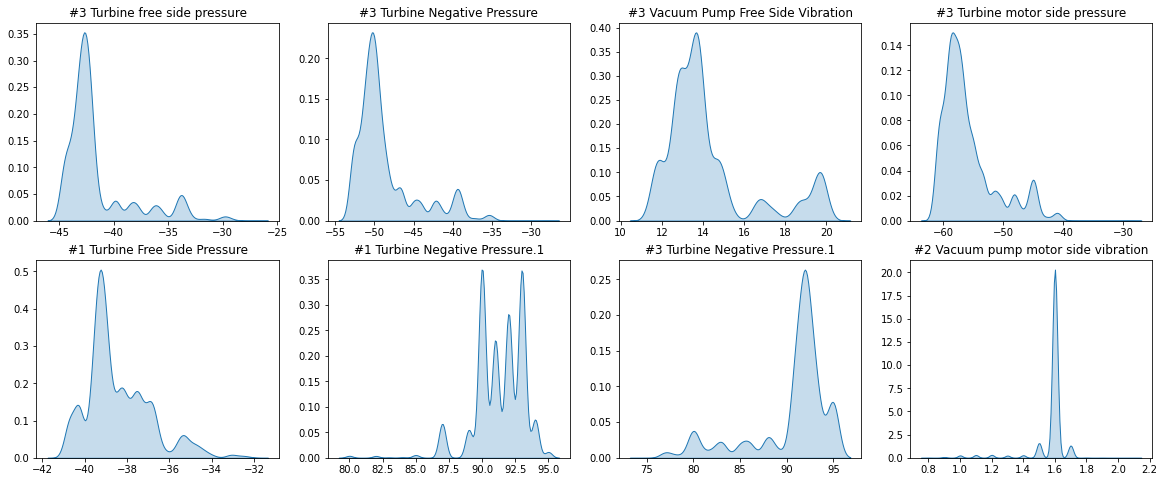

In [18]:
a, b = 2, 4
k = 0
fig, ax = plt.subplots(a, b, figsize = (20, 8))
for i in range(a):
    for j in range(b):
        sns.kdeplot(data = df, x = skewness["Feature"].iloc[k], shade=True, ax = ax[i, j])
        ax[i, j].set(ylabel = None, xlabel = None, title = skewness["Feature"].iloc[k])
        k += 1

In [19]:
pt = PowerTransformer(method = 'yeo-johnson')
df[skewness["Feature"]] = pt.fit_transform(df[skewness["Feature"]])
# '#2 Vacuum pump motor side vibration'轉換效果不佳，但對模型的表現仍有幫助

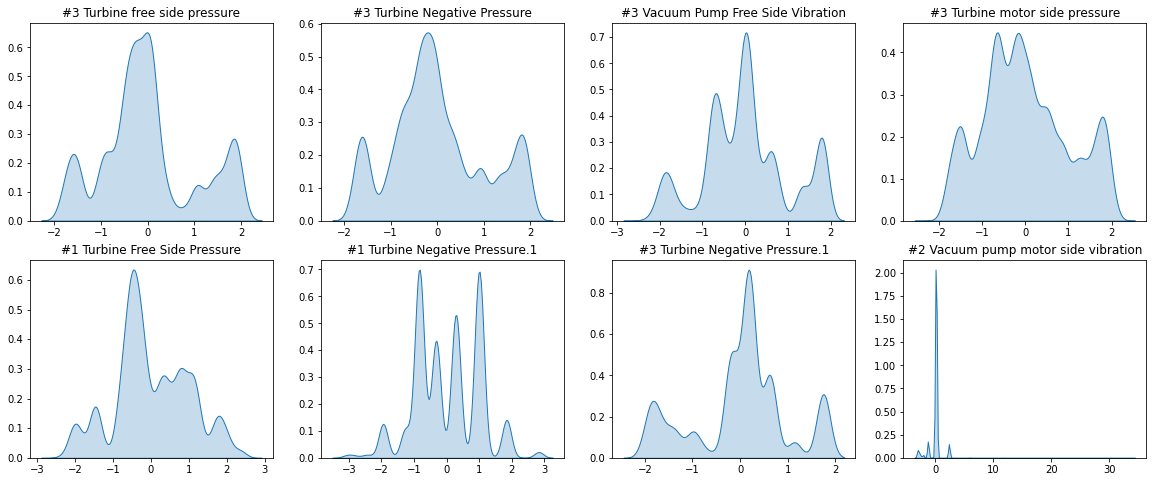

In [20]:
a, b = 2, 4
k = 0
fig, ax = plt.subplots(a, b, figsize = (20, 8))
for i in range(a):
    for j in range(b):
        sns.kdeplot(data = df, x = skewness["Feature"].iloc[k], shade=True, ax = ax[i, j])
        ax[i, j].set(ylabel = None, xlabel = None, title = skewness["Feature"].iloc[k])
        k += 1

#### Scaling

In [21]:
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

## Modeling

#### Split data

In [22]:
train_data, test_data = train_test_split(df, test_size = 0.3, shuffle = True)
train_data, valid_data = train_test_split(train_data, test_size = 0.3, shuffle = True)
print(train_data.shape, valid_data.shape, test_data.shape)

(8108, 28) (3476, 28) (4965, 28)


#### Select device

In [23]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# print(device)

#### Data transform to Torch Dataset

In [24]:
class Dataset_transform(Dataset):
    def __init__(self, df, features, target):
        self.n_samples = len(df)
        self.X = torch.Tensor(df[features].values)#.to(device)
        self.y = torch.Tensor(df[target].values.reshape(-1, 1))#.to(device)
                                            
    def __len__(self):
        return self.n_samples

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [25]:
train_dataset = Dataset_transform(train_data, features, target)
valid_dataset = Dataset_transform(valid_data, features, target)
test_dataset = Dataset_transform(test_data, features, target)

#### DataLoader to use for batch

In [26]:
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size = batch_size)
valid_dataloader = DataLoader(valid_dataset, batch_size = len(valid_dataset))
test_dataloader = DataLoader(test_dataset, batch_size = len(test_dataset))

#### Model structure

In [27]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(27, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        x = self.net(x)
        return x

In [28]:
epochs = 500
model = Model()#.to(device)
criterion = nn.MSELoss()#.to(device)
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

#### Initialize weights

In [29]:
# 初始化權重，使其符合常態分布
for m in model.modules():
    if isinstance(m, (nn.Linear)):
        nn.init.kaiming_normal_(m.weight)

#### Training model

In [30]:
# validate、test預測後的損失函數，以及相關分數
def eval(dataloader, model, criterion, mode = "eval"):
    losses = 0
    pred1, y1 = torch.Tensor([]), torch.Tensor([])
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X) #預測
        loss = criterion(pred, y) #計算損失函數
        losses += loss.item()

        # pred, y = pred.cpu(), y.cpu()
        pred1 = torch.concat([pred1, pred])
        y1 = torch.concat([y1, y])

    losses /= (batch + 1)

    if mode == "train":
        return losses
        
    pred1 = pred1.detach().numpy()
    y1 = y1.detach().numpy()
    MSE = mean_squared_error(pred1, y1)
    RMSE = MSE ** (1/2)
    MAPE = mean_absolute_percentage_error(pred1, y1)
    R2 = r2_score(pred1, y1)
    
    return MSE, RMSE, MAPE, R2, pred1, y1

In [ ]:
# 建模
best_loss = np.inf
paitence = 30
train_losses = []
valid_losses = []
for epoch in range(epochs):
    train_loss = 0
    valid_loss = 0
    # train model
    model.train() # 模型為訓練模式
    for batch, (X_train, y_train) in enumerate(train_dataloader):
        train_pred = model(X_train) #預測
        loss = criterion(train_pred, y_train) #計算損失函數

        optimizer.zero_grad() # 梯度在反向傳播前先清零
        loss.backward() # 反向傳播，計算權重對損失函數的梯度
        optimizer.step()  # 根據梯度更新權重
        train_loss += loss.item()
    train_loss /= (batch + 1)
    train_losses.append(train_loss)

    # validate model
    model.eval()# 模型為評估模式
    valid_loss = eval(valid_dataloader, model, criterion, mode = "train")
    valid_losses.append(valid_loss)

    print(f"Epoch {epoch} - train_loss: {train_loss:.4f},  valid_loss: {valid_loss:.4f}")

    # 損失函數連續30個epoches都沒下降的話就終止訓練
    if valid_loss < best_loss:
        best_loss = valid_loss
        remain_patience = paitence
    else:
        remain_patience -= 1
        if remain_patience == 0:
            print('early stop!')
            break
print("Done!")

#### Predict

In [32]:
data_name = ["Train", "Validation", "Test"]
dataloaders = [train_dataloader, valid_dataloader, test_dataloader]
score = pd.DataFrame(columns = ["MSE", "RMSE", "MAPE", "R2"])
result = {}

for name, dataloader in zip(data_name, dataloaders):
    MSE, RMSE, MAPE, R2, pred, true = eval(dataloader, model, criterion)
    score.loc[name] = [MSE, RMSE, MAPE, R2]
    result[name] = {
        "true": true.reshape(-1),
        "pred": pred.reshape(-1),
    }

train_result = pd.DataFrame(result["Train"])
valid_result = pd.DataFrame(result["Validation"])
test_result = pd.DataFrame(result["Test"])
score.round(4)

,MSE,RMSE,MAPE,R2
Train,0.2398,0.4897,0.0077,0.9339
Validation,0.3085,0.5554,0.0084,0.9161
Test,0.2569,0.5068,0.0082,0.9304


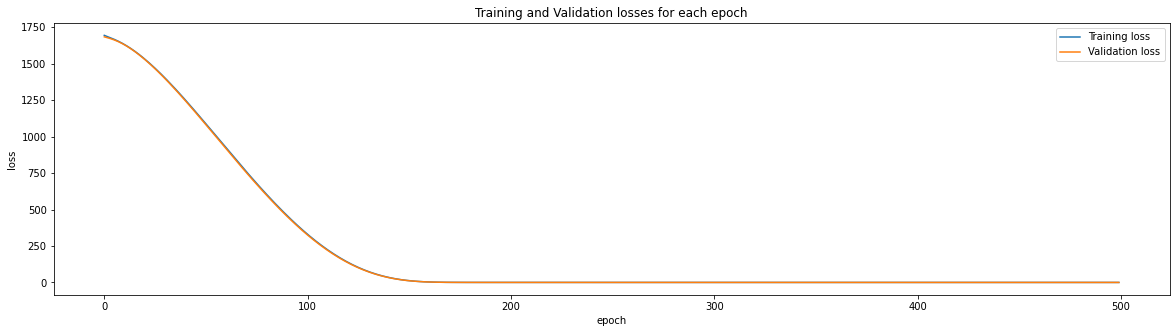

In [33]:
plt.figure(figsize=(20,5))
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.title("Training and Validation losses for each epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

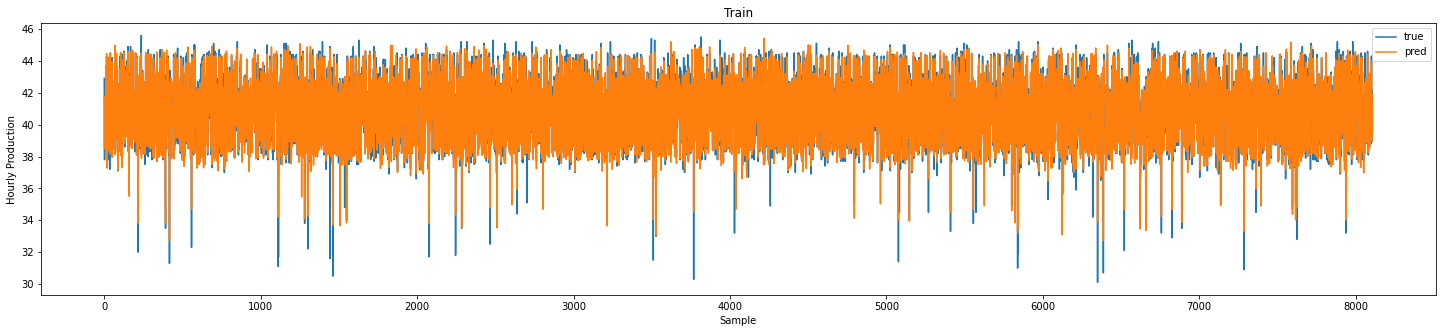

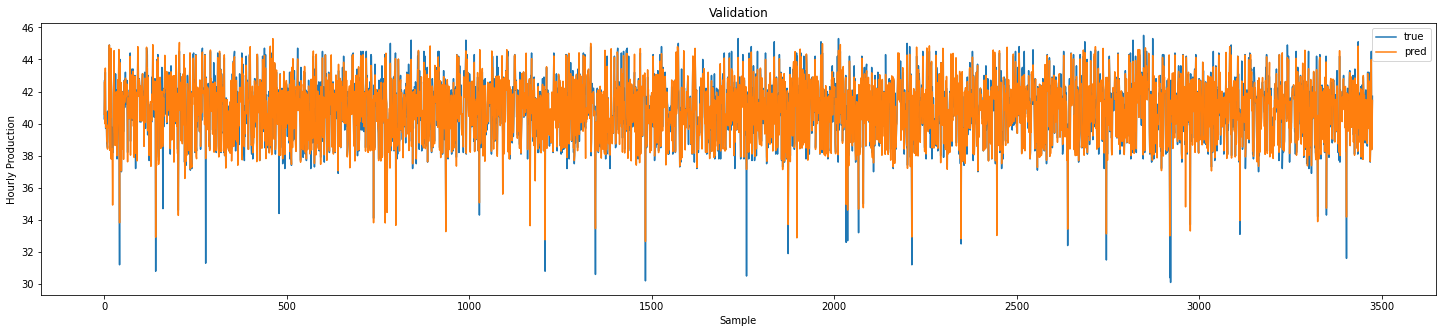

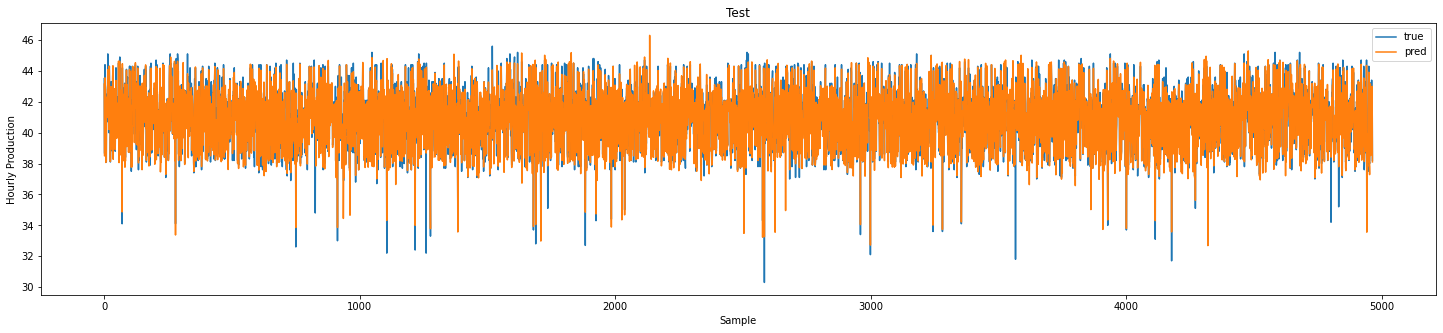

In [34]:
data = [train_result, valid_result, test_result]
for i in range(3):
    data[i].plot(figsize = (25, 5), title = data_name[i])
    plt.xlabel("Sample")
    plt.ylabel("Hourly Production")

## Save

In [35]:
# 儲存model
skew_feat = skewness["Feature"].to_list()
pickle.dump(skew_feat, open('model/skew_feat.pkl','wb'))
pickle.dump(pt, open('model/power_tf.pkl','wb'))
pickle.dump(scaler, open('model/scaler.pkl','wb'))
torch.save(model.state_dict(), "model/nn_weights.pt") # 儲存權重

In [36]:
# 抓出產出超過40的sample的所有freature之四分位數
df40 = df[(df["Hourly Production"] >= 40)][features]
df40_range = df40.describe().T[["25%", "50%", "75%"]]
df40_range = df40_range.reset_index()
df40_range = df40_range.rename(columns = {"index": "feature"})
df40_range.to_csv("model/output40.csv", index = False)

In [37]:
# 找出input data的離群值邊界
df1 = pd.read_csv("data/drop_outlier.csv")
df_range = df1[features]
df_range = df_range.describe().T[["25%", "75%"]]
IQR = df_range["75%"] - df_range["25%"]
df_range["min"] = df_range["25%"] - 1.5 * IQR
df_range["max"] = df_range["75%"] + 1.5 * IQR
df_range.to_csv("model/input_range.csv", index = False)

## Input X optimize

#### Load model

In [39]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(27, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        x = self.net(x)
        return x

In [40]:
# 載入訓練好的模型
skew_feat = pickle.load(open('model/skew_feat.pkl','rb'))
pt = pickle.load(open('model/power_tf.pkl','rb'))
scaler = pickle.load(open('model/scaler.pkl','rb'))

model = Model()
model.load_state_dict(torch.load("model/nn_weights.pt")) # 更該model權重
model.eval()

Model(
  (net): Sequential(
    (0): Linear(in_features=27, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

#### Input X

In [41]:
import random

# 輸入參數
df0 = pd.read_csv("data/data.csv")
features = df0.columns[5:].to_list()
df_lower40 = df0[(df0["Hourly Production"] < 40)]["Hourly Production"]
ind = random.choice(df_lower40.index)
output = df0.loc[ind, "Hourly Production"]
init_X = df0.iloc[ind: ind+1][features]

# 指定不可調動的參數
fixed_mask = [random.randint(0, 1) for i in range(27)]

#### Transform X

In [42]:
X = init_X.copy()
X[skew_feat] = pt.transform(X[skew_feat])
X[features] = scaler.transform(X[features])
X = X.values.reshape(1, -1)
X = torch.Tensor(X)

print("output =", output)
print("initial X =", init_X.values)
print("transform X =", X)
print("fixed mask =", fixed_mask)

output = 38.5
initial X = [[-26.4 -36.6 -31.5  90.   87.6  13.3   6.4 -49.9 -62.3 -56.1  90.   59.6
    1.6  21.1 -55.4 -42.3 -48.8  92.   90.3   0.6  13.8 -48.8 -48.8 100.
   83.3  12.2   3.3]]
transform X = tensor([[ 1.0632,  1.2543,  1.3946, -0.8327,  1.0434, -0.8579, -0.0153, -0.6179,
         -0.5657, -0.6349,  0.9778,  1.9357,  0.1324,  0.5255,  0.4328,  0.0325,
          0.3213,  0.1896,  1.7626, -0.1820,  0.0769,  1.0971,  1.0971,  0.0000,
          1.0788, -1.1324,  1.2287]])
fixed mask = [1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1]


#### Check X is in distribution range

In [43]:
# 產出超過40的sample的所有freature之四分位數
df40_range = pd.read_csv("model/output40.csv")
df40_range.head(3)

,feature,25%,50%,75%
0,#1 Turbine motor side pressure,-0.965940,-0.584219,0.078771
1,#1 Turbine Free Side Pressure,-0.686335,-0.418224,0.350699
2,#1 Turbine Negative Pressure,-1.030381,-0.600135,0.025677


In [44]:
# 查看輸入的參數是否在25% ~ 75%之間
for j, x in enumerate(X[0]):
    if (x < df40_range.iloc[j, 1]) or (x > df40_range.iloc[j, 3]):
        if (fixed_mask[j] == 0):
            print(f"{j} : ({round(float(x), 4)}) not in {df40_range.iloc[j, 1].round(4)} ~ {df40_range.iloc[j, 3].round(4)}")
        else:
            print(f"{j} : ({round(float(x), 4)}) not in {df40_range.iloc[j, 1].round(4)} ~ {df40_range.iloc[j, 3].round(4)},  but parameter is fixed.")

0 : (1.0632) not in -0.9659 ~ 0.0788,  but parameter is fixed.
1 : (1.2543) not in -0.6863 ~ 0.3507
2 : (1.3946) not in -1.0304 ~ 0.0257,  but parameter is fixed.
3 : (-0.8327) not in -0.3183 ~ 1.0042,  but parameter is fixed.
4 : (1.0434) not in -0.896 ~ 0.2461,  but parameter is fixed.
5 : (-0.8579) not in -0.4544 ~ 0.7559
11 : (1.9357) not in -1.089 ~ 0.214,  but parameter is fixed.
18 : (1.7626) not in -0.9943 ~ 0.5847,  but parameter is fixed.
21 : (1.0971) not in -0.9064 ~ 0.2722
22 : (1.0971) not in -0.9064 ~ 0.2722
24 : (1.0788) not in -0.6264 ~ 0.8302,  but parameter is fixed.
25 : (-1.1324) not in -0.9191 ~ 1.0002,  but parameter is fixed.
26 : (1.2287) not in -1.1193 ~ 0.6417,  but parameter is fixed.


In [45]:
# 如果輸入的參數不在25% ~ 75%之間，就用中位數取代
print("init X:", X)
for j, x in enumerate(X[0]):
    if ((x < df40_range.iloc[j, 1]) or (x > df40_range.iloc[j, 3])) and (fixed_mask[j] == 0):
        X[0][j] = df40_range.iloc[j, 2]
print("new X:", X)

init_pred = model(X).item()
print("Predict =", init_pred)
if (init_pred < 0) or (init_pred > 50):
    print("Unable to optimize X.")

init X: tensor([[ 1.0632,  1.2543,  1.3946, -0.8327,  1.0434, -0.8579, -0.0153, -0.6179,
         -0.5657, -0.6349,  0.9778,  1.9357,  0.1324,  0.5255,  0.4328,  0.0325,
          0.3213,  0.1896,  1.7626, -0.1820,  0.0769,  1.0971,  1.0971,  0.0000,
          1.0788, -1.1324,  1.2287]])
new X: tensor([[ 1.0632, -0.4182,  1.3946, -0.8327,  1.0434, -0.0510, -0.0153, -0.6179,
         -0.5657, -0.6349,  0.9778,  1.9357,  0.1324,  0.5255,  0.4328,  0.0325,
          0.3213,  0.1896,  1.7626, -0.1820,  0.0769, -0.2582, -0.2582,  0.0000,
          1.0788, -1.1324,  1.2287]])
Predict = 38.944942474365234


In [46]:
# 查看輸入的參數是否在25% ~ 75%之間
for j, x in enumerate(X[0]):
    if (x < df40_range.iloc[j, 1]) or (x > df40_range.iloc[j, 3]):
        if (fixed_mask[j] == 0):
            print(f"{j} : ({round(float(x), 4)}) not in {df40_range.iloc[j, 1].round(4)} ~ {df40_range.iloc[j, 3].round(4)}")
        else:
            print(f"{j} : ({round(float(x), 4)}) not in {df40_range.iloc[j, 1].round(4)} ~ {df40_range.iloc[j, 3].round(4)}, but parameter is fixed.")

0 : (1.0632) not in -0.9659 ~ 0.0788, but parameter is fixed.
2 : (1.3946) not in -1.0304 ~ 0.0257, but parameter is fixed.
3 : (-0.8327) not in -0.3183 ~ 1.0042, but parameter is fixed.
4 : (1.0434) not in -0.896 ~ 0.2461, but parameter is fixed.
11 : (1.9357) not in -1.089 ~ 0.214, but parameter is fixed.
18 : (1.7626) not in -0.9943 ~ 0.5847, but parameter is fixed.
24 : (1.0788) not in -0.6264 ~ 0.8302, but parameter is fixed.
25 : (-1.1324) not in -0.9191 ~ 1.0002, but parameter is fixed.
26 : (1.2287) not in -1.1193 ~ 0.6417, but parameter is fixed.


#### Optimize

In [ ]:
start = time.time()
preds = []
losses = []
target = 41
h = 1e-4 # 參數的變化量
learn_rate = 0.001
best_loss = np.inf
loss_limit = 100
boundary = target - 0.1 
boundary_limit = 30
time_limit = 40
epoch = 1
beta1 = 0.9
beta2 = 0.999
eps = 1e-08
v = torch.zeros(len(X[0]))
s = torch.zeros(len(X[0]))
# 如果參數調成中位數就已經滿足產出>=target，直接返回參數
if model(X) < target:
    while True:
        for i in range(len(X[0])):
            # 若該參數為固定值，梯度為0，不更新參數
            if fixed_mask[i]:
                continue
            
            # 計算梯度: dloss_dx = (loss(x+h) - loss(x-h)) / (2*h)
            X_up = X.clone()
            X_down = X.clone()
            
            X_up[0][i] += h
            X_down[0][i] -= h

            loss_up = (target - model(X_up)) ** 2
            loss_down = (target - model(X_down)) ** 2

            dloss_dx = (loss_up - loss_down) / (2 * h)

            # 以Adam的方式更新參數，需先計算v、s
            # v = bata1 * v + (1 - beta1) * dloss_dweight  # Momentum: 累積過去梯度，讓跟當前趨勢同方向的參數有更多的更新，即沿著動量的方向越滾越快
            # s = bata2 * s + (1 - beta2) * (dloss_dweight ⊙ dloss_dweight) # Adagrad: 累積過去梯度，以獲得參數被修正程度，修正大的參數學習率會逐漸變小
            v[i] = (beta1 * v[i]) + ((1 - beta1) * dloss_dx.item())
            s[i] = beta2 * s[i] + (1 - beta2) * (dloss_dx.item() ** 2)

        # 透過梯度計算新的參數
        # weight = weight - learning_rate * (1 / ((s + eps) ** (1/2))) * v  # eps: 是極小值，避免s為0時發生除以0的情況
        grad = (learn_rate * (1 / ((s + eps) ** (1/2))) * v)
        new_X = X[0] - grad

        # 確認新參數是否在25%~75%的分布範圍內，並將不在分布範圍內的新參數的梯度轉為0，此次不更新該參數
        mask = [True if (new_x >= df40_range.iloc[j, 1]) and (new_x <= df40_range.iloc[j, 3]) else False for j, new_x in enumerate(new_X)]
        mask = torch.Tensor(mask)
        grad *= mask

        # 更新參數
        X[0] -= grad

        # 查看新預測結果
        pred = model(X).item()
        preds.append(pred)

        loss = (target - pred) ** 2
        losses.append(loss)
        print(f"Epoch {epoch} - loss: {loss:.4f},  predict: {pred:.4f}")

        # 損失函數連續100個epoches都沒下降的話就終止訓練
        if loss < best_loss:
            best_loss = loss
            remain_loss = loss_limit
        else:
            remain_loss -= 1
            if remain_loss == 0:
                print('early stop!')
                break

        # 預測產出達標就終止訓練
        if (pred < boundary):
            remain_boundary = boundary_limit
        else:
            remain_boundary -= 1
            if remain_boundary == 0:
                print('early stop!')
                break

        # 時間到就終止訓練
        end = time.time()
        if ((end - start) > time_limit):
            print('Done!')
            break
        else:
            epoch += 1
else:
    pred = model(X).item()
    print(f"update X to medium - predict: {pred}")

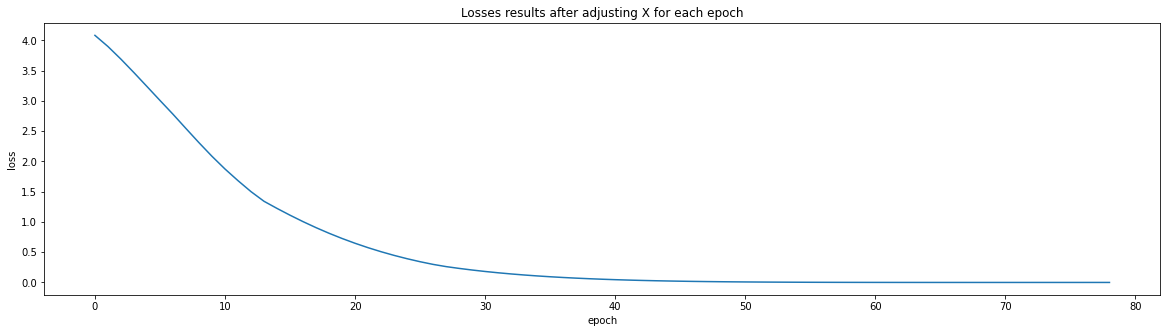

In [48]:
plt.figure(figsize=(20,5))
plt.plot(losses)
plt.title("Losses results after adjusting X for each epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

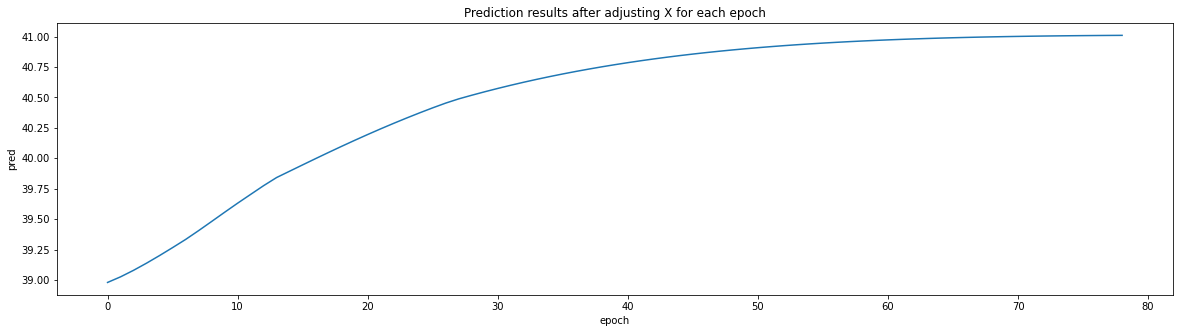

In [49]:
plt.figure(figsize=(20,5))
plt.plot(preds)
plt.title("Prediction results after adjusting X for each epoch")
plt.xlabel("epoch")
plt.ylabel("pred")
plt.show()

#### Inverse transform X

In [50]:
X1 = pd.DataFrame(X, columns = features, index = ["new"])
X1[features] = scaler.inverse_transform(X1[features])
X1[skew_feat] = pt.inverse_transform(X1[skew_feat])
X1 = X1.apply(lambda x: round(x.astype(np.float64), 1))

#### Final check

In [51]:
# 檢測是否有不可調動的參數被調動
init_X.index = ["init"]
update = pd.concat([init_X, X1]).T
update["fixed"] = fixed_mask
update["change"] = update.eval("(init != new)").astype(int)
update["check"] = update.eval("not ((init != new) & fixed)").astype(int)
update["pred"] = round(pred, 1)

In [52]:
# 檢測X轉為小數點後一位後，是否會對predict有影響
X2 = X1.copy()
X2[skew_feat] = pt.transform(X2[skew_feat])
X2[features] = scaler.transform(X2[features])
X2 = X2.values.reshape(1, -1)
X2 = torch.Tensor(X2)
new_pred = model(X2).item()
update["pred_0.1"] = round(new_pred, 1)
update

,init,new,fixed,change,check,pred,pred_0.1
#1 Turbine motor side pressure,-26.4,-26.4,1,0,1,41.0,41.0
#1 Turbine Free Side Pressure,-36.6,-39.4,0,1,1,41.0,41.0
#1 Turbine Negative Pressure,-31.5,-31.5,1,0,1,41.0,41.0
#1 Turbine Negative Pressure.1,90.0,90.0,1,0,1,41.0,41.0
#1 Turbine Main Motor Current,87.6,87.6,1,0,1,41.0,41.0
#1 Vacuum Pump Motor Side vibration,13.3,13.8,0,1,1,41.0,41.0
#1 Free side vibration of vacuum pump,6.4,6.3,0,1,1,41.0,41.0
#2 Turbine motor side pressure,-49.9,-50.0,0,1,1,41.0,41.0
#2 Turbine free side pressure,-62.3,-62.3,1,0,1,41.0,41.0
#2 Turbine negative pressure,-56.1,-56.1,1,0,1,41.0,41.0
